# การทำนายสถานะกิจการและความเสี่ยงในการยกเลิกจดทะเบียนภาษีมูลค่าเพิ่มด้วยข้อมูลภูมิสารสนเทศ
## (Geospatial Analysis & VAT Risk Prediction Workflow for Beginners)

สมุดบันทึกเล่มนี้ออกแบบมาสำหรับ**ผู้เริ่มต้นศึกษา Data Science** โดยแสดงทุกขั้นตอนอย่างละเอียด ตั้งแต่การโหลดข้อมูลดิบ, การสำรวจข้อมูล (EDA), การคลีนและจัดการค่าสูญหาย (NaN), การลดมิติด้วย PCA, การจัดกลุ่มเชิงพื้นที่ (Clustering) ไปจนถึงการสร้างโมเดลทำนาย (Machine Learning) พร้อมใช้กราฟแบบโต้ตอบได้ของ **Plotly** ในการแสดงผล

---

## ขั้นตอนที่ 1: การนำเข้าห้องสมุด (Import Libraries)
เราจะใช้ไลบรารีมาตรฐานสำหรับ Data Science ได้แก่:
* `pandas` & `numpy` สำหรับจัดการโครงสร้างข้อมูลแบบตารางและเวกเตอร์
* `plotly` สำหรับสร้างกราฟ Interactive
* `sklearn` (scikit-learn) สำหรับการสเกลข้อมูล, ทำ PCA, รัน K-Means, และเทรน Random Forest

In [1]:
import os
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from datetime import datetime

# นำเข้าโมดูลของ scikit-learn สำหรับการทำเหมืองข้อมูลและสร้างแบบจำลอง
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, classification_report, roc_curve, auc

# ตั้งค่าเริ่มต้นเพื่อแก้ปัญหากราฟ Plotly ไม่แสดงผลใน GitHub (ใช้ png renderer เพื่อไม่ให้เกิด MIME type conflict)
pio.renderers.default = 'png'

import warnings
warnings.filterwarnings('ignore')
print("นำเข้าห้องสมุดเรียบร้อยแล้ว!")

นำเข้าห้องสมุดเรียบร้อยแล้ว!


## ขั้นตอนที่ 2: การโหลดข้อมูลและสำรวจเบื้องต้น (Data Loading & Exploratory Data Analysis)
ในส่วนนี้เราจะโหลดข้อมูลจริงผู้ประกอบการ VAT มาลองแสดงข้อมูลดูขนาดตาราง (`.shape`), ประเภทข้อมูลแต่ละคอลัมน์ (`.info()`), สถิติเชิงบรรยาย (`.describe()`) และแสดงตัวอย่างแถวข้อมูล (`display(head)`)

In [2]:
PATH_VAT_BKK = "gdpublish-vat-taxpayeraddress/vat_taxpayeraddress_01.csv"
PATH_VAT_PROV = "gdpublish-vat-taxpayeraddress/VAT_TaxpayerAddress_02.csv"

# เราเลือกใช้เฉพาะคอลัมน์สำคัญเพื่อลดการใช้หน่วยความจำและทำให้ประมวลผลเร็วขึ้น
cols_to_use = ['เลขผู้เสียภาษีอากร', 'จังหวัด', 'อำเภอ', 'ตำบล', 'รหัสไปรษณีย์ ', 'วันที่ได้รับอนุมัติ']

print("1. โหลดข้อมูลกรุงเทพมหานคร (ตัวเข้ารหัส: TIS-620)...")
df_bkk = pd.read_csv(PATH_VAT_BKK, encoding='tis-620', encoding_errors='ignore', usecols=cols_to_use, low_memory=False)
df_bkk.columns = df_bkk.columns.str.strip()

print("2. โหลดข้อมูลส่วนต่างจังหวัด (ตัวเข้ารหัส: UTF-8-sig)...")
df_prov = pd.read_csv(PATH_VAT_PROV, encoding='utf-8-sig', encoding_errors='ignore', usecols=cols_to_use, low_memory=False)
df_prov.columns = df_prov.columns.str.strip()

# รวมสองตารางเข้าด้วยกัน
df = pd.concat([df_bkk, df_prov], ignore_index=True)

print("\n--- 3. ผลสำรวจเบื้องต้น (Exploratory Data Analysis) ---")
print(f"ขนาดตาราง (แถว, คอลัมน์): {df.shape}")
print("\nประเภทข้อมูลของแต่ละคอลัมน์ (df.info()):")
df.info()

print("\nตัวอย่างข้อมูล 5 แถวแรก:")
display(df.head())

print("\nสถิติเชิงบรรยายภาพรวม (df.describe):")
display(df.describe(include='all'))

1. โหลดข้อมูลกรุงเทพมหานคร (ตัวเข้ารหัส: TIS-620)...


2. โหลดข้อมูลส่วนต่างจังหวัด (ตัวเข้ารหัส: UTF-8-sig)...



--- 3. ผลสำรวจเบื้องต้น (Exploratory Data Analysis) ---
ขนาดตาราง (แถว, คอลัมน์): (1173568, 6)

ประเภทข้อมูลของแต่ละคอลัมน์ (df.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1173568 entries, 0 to 1173567
Data columns (total 6 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   เลขผู้เสียภาษีอากร   1173568 non-null  object
 1   ตำบล                 1173399 non-null  object
 2   อำเภอ                1173399 non-null  object
 3   จังหวัด              1173399 non-null  object
 4   รหัสไปรษณีย์         1173317 non-null  object
 5   วันที่ได้รับอนุมัติ  1173317 non-null  object
dtypes: object(6)
memory usage: 53.7+ MB

ตัวอย่างข้อมูล 5 แถวแรก:


,เลขผู้เสียภาษีอากร,ตำบล,อำเภอ,จังหวัด,รหัสไปรษณีย์,วันที่ได้รับอนุมัติ
0,10341288306,คลองจั่น,บางกะปิ,กรุงเทพมหานคร,10240,2559-09-22
1,10341310450,คลองจั่น,บางกะปิ,กรุงเทพมหานคร,10240,2559-10-03
2,100508000326,จตุจักร,จตุจักร,กรุงเทพมหานคร,10900,2535-01-01
3,100508000326,ช่องนนทรี,ยานนาวา,กรุงเทพมหานคร,10120,2535-01-01
4,100508000326,สีกัน,ดอนเมือง,กรุงเทพมหานคร,10210,2535-01-01



สถิติเชิงบรรยายภาพรวม (df.describe):


,เลขผู้เสียภาษีอากร,ตำบล,อำเภอ,จังหวัด,รหัสไปรษณีย์,วันที่ได้รับอนุมัติ
count,1173568,1173399,1173399,1173399,1173317,1173317
unique,926994,5853,983,158,1639,11333
top,0105537086432,ในเมือง,บางพลี,กรุงเทพมหานคร,10110,2535-01-01
freq,12754,23050,25556,377346,29420,33453


## ขั้นตอนที่ 3: การคลีนข้อมูลและการจัดการค่าสูญหาย (Data Cleaning & Handling NaN)
การเตรียมข้อมูล (Data Cleansing) เป็นขั้นตอนสำคัญที่สุดในการทำ Data Science ในที่นี้เราจะ:
1. ตรวจสอบจำนวนค่าที่สูญหาย (NaN) ในแต่ละคอลัมน์
2. จัดการข้อมูลประเภทวันที่ (ย้ายจากปฏิทิน พ.ศ. ไปเป็น ค.ศ. สากล)
3. คำนวณอายุการทำงานของธุรกิจ (`business_age_years`)
4. ตรวจสอบข้อมูลหลังคลีนอีกครั้ง

In [3]:
print("1. ตรวจสอบจำนวนค่าว่าง (NaN) ก่อนทำการคลีนข้อมูล:")
print(df.isna().sum())

def clean_be_date(date_str):
    if pd.isna(date_str) or not isinstance(date_str, str):
        return pd.NaT
    try:
        parts = date_str.split('-')
        if len(parts) == 3:
            year, month, day = int(parts[0]), int(parts[1]), int(parts[2])
            if year > 2400: # ถ้าเป็นปี พ.ศ. ให้แปลงกลับเป็น ค.ศ. โดยลบ 543
                year -= 543
            return pd.Timestamp(year=year, month=month, day=day)
    except:
        pass
    return pd.NaT

print("\n2. กำลังแปลงข้อมูลวันที่และลบแถวที่เป็นค่าว่าง...")
df['registration_date'] = df['วันที่ได้รับอนุมัติ'].apply(clean_be_date)
df = df.dropna(subset=['registration_date'])

# คำนวณอายุขัยทางธุรกิจ (ณ วันที่ 2026-07-10)
ref_date = pd.Timestamp('2026-07-10')
df['business_age_years'] = (ref_date - df['registration_date']).dt.days / 365.25
df = df[df['business_age_years'] >= 0]

# ทำความสะอาดช่องว่างส่วนเกินในคอลัมน์ที่เป็นข้อความ
df['จังหวัด'] = df['จังหวัด'].astype(str).str.strip()
df['อำเภอ'] = df['อำเภอ'].astype(str).str.strip()
df['ตำบล'] = df['ตำบล'].astype(str).str.strip()

print("\n3. ตรวจสอบจำนวนค่าว่าง (NaN) หลังลบแถวที่คีย์ข้อมูลวันที่ไม่ได้:")
print(df.isna().sum())
print(f"\nจำนวนแถวข้อมูลคงเหลือสำหรับการทำงาน: {df.shape[0]:,}")

1. ตรวจสอบจำนวนค่าว่าง (NaN) ก่อนทำการคลีนข้อมูล:
เลขผู้เสียภาษีอากร       0
ตำบล                   169
อำเภอ                  169
จังหวัด                169
รหัสไปรษณีย์           251
วันที่ได้รับอนุมัติ    251
dtype: int64

2. กำลังแปลงข้อมูลวันที่และลบแถวที่เป็นค่าว่าง...



3. ตรวจสอบจำนวนค่าว่าง (NaN) หลังลบแถวที่คีย์ข้อมูลวันที่ไม่ได้:
เลขผู้เสียภาษีอากร     0
ตำบล                   0
อำเภอ                  0
จังหวัด                0
รหัสไปรษณีย์           0
วันที่ได้รับอนุมัติ    0
registration_date      0
business_age_years     0
dtype: int64

จำนวนแถวข้อมูลคงเหลือสำหรับการทำงาน: 1,173,317


## ขั้นตอนที่ 4: การสกัดคุณลักษณะเชิงพื้นที่และเศรษฐกิจ (Geospatial Feature Engineering)
เพื่อทำให้ตัวแบบรับรู้ถึงปัจจัยภูมิสารสนเทศ เราจะคำนวณสองฟีเจอร์สำคัญ:
1. **Business Density:** จำนวนธุรกิจที่แอคทีฟในรหัสไปรษณีย์และอำเภอเดียวกัน (ดัชนีชี้การกระจุกตัวและการแข่งขัน)
2. **Provincial Tax Pulse:** ดึงข้อมูลจากไฟล์ `gdpublish-ds-taxsumprov` เพื่อหาอัตราการเติบโตทางเศรษฐกิจ (ความชัน/Slope) ของภาษีมูลค่าเพิ่มรายจังหวัดในช่วงปี 2565-2568

In [4]:
print("1. คำนวณความหนาแน่นผู้ประกอบการรายรหัสไปรษณีย์และอำเภอ...")
postcode_counts = df['รหัสไปรษณีย์'].value_counts().to_dict()
df['postcode_business_density'] = df['รหัสไปรษณีย์'].map(postcode_counts)

dist_counts = df.groupby(['จังหวัด', 'อำเภอ']).size().reset_index(name='district_business_density')
df = df.merge(dist_counts, on=['จังหวัด', 'อำเภอ'], how='left')

print("2. ประมวลผลดัชนีแนวโน้มภาษีมูลค่าเพิ่มรายจังหวัด...")
DIR_TAX_PROV = "gdpublish-ds-taxsumprov"
tax_files = {2565: "taxsumprov_2565.csv", 2566: "taxsumprov_2566.csv", 2567: "-2567.csv", 2568: "data2_2568.csv"}
prov_tax_list = []

for year, fn in tax_files.items():
    fp = os.path.join(DIR_TAX_PROV, fn)
    if os.path.exists(fp):
        for enc in ['utf-8', 'tis-620', 'cp874']:
            try:
                df_t = pd.read_csv(fp, encoding=enc)
                df_t.columns = df_t.columns.str.strip()
                if 'PROV' in df_t.columns:
                    df_t['year'] = year
                    df_t['TAX_TYPE'] = df_t['TAX_TYPE'].astype(str).str.strip().str.lstrip('0')
                    df_vat = df_t[df_t['TAX_TYPE'] == '5'] # ประเภทภาษี 5 = ภาษีมูลค่าเพิ่ม
                    prov_tax_list.append(df_vat)
                    break
            except:
                continue

df_all_tax = pd.concat(prov_tax_list, ignore_index=True)
df_all_tax['PROV'] = df_all_tax['PROV'].astype(str).str.strip()
df_all_tax['AMT_RCV'] = pd.to_numeric(df_all_tax['AMT_RCV'], errors='coerce').fillna(0.0)
yearly_vat = df_all_tax.groupby(['PROV', 'year'])['AMT_RCV'].sum().reset_index()

slopes = {}
for prov, group in yearly_vat.groupby('PROV'):
    if len(group) >= 2:
        group = group.sort_values('year')
        x, y = group['year'].values, group['AMT_RCV'].values
        slope, _ = np.polyfit(x, y, 1)
        avg_rev = np.mean(y)
        slopes[prov] = slope / avg_rev if avg_rev > 0 else 0.0
    else:
        slopes[prov] = 0.0

df['prov_vat_trend_slope'] = df['จังหวัด'].map(slopes).fillna(0.0)

# สุ่มตัวอย่าง 100,000 แถวเพื่อให้กระบวนการทำงานได้รวดเร็วและใช้แรมอย่างประหยัด
df_sample = df.sample(n=min(100000, df.shape[0]), random_state=42)
print(f"ทำ Feature Engineering เสร็จแล้ว! ตัวอย่างเก็บไว้: {df_sample.shape[0]:,} แถว")
display(df_sample[['จังหวัด', 'อำเภอ', 'business_age_years', 'postcode_business_density', 'prov_vat_trend_slope']].head())

1. คำนวณความหนาแน่นผู้ประกอบการรายรหัสไปรษณีย์และอำเภอ...


2. ประมวลผลดัชนีแนวโน้มภาษีมูลค่าเพิ่มรายจังหวัด...
ทำ Feature Engineering เสร็จแล้ว! ตัวอย่างเก็บไว้: 100,000 แถว


,จังหวัด,อำเภอ,business_age_years,postcode_business_density,prov_vat_trend_slope
44454,กรุงเทพมหานคร,จอมทอง,34.450376,26369,0.000000
963431,ชลบุรี,บางละมุง,10.819986,14446,0.004958
96458,กรุงเทพมหานคร,สะพานสูง,22.836413,27192,0.000000
908918,สุราษฎร์ธานี,เมืองสุราษฎร์ธานี,8.574949,5208,0.113528
834740,ชัยนาท,สรรคบุรี,11.904175,335,0.067832


## ขั้นตอนที่ 5: การลดมิติข้อมูลด้วย PCA (Principal Component Analysis)
เนื่องจากข้อมูลอาจมีความหนาแน่นหลายระดับที่มีความเกี่ยวข้องกันสูง (Multicollinearity) เราจะใช้ **PCA** ในการดึงเอาส่วนประกอบหลัก (Principal Components) 2 ตัวแปรเพื่ออธิบายลักษณะเชิงพื้นที่ และทำการสเกลข้อมูลให้อยู่ในมาตรฐานเดียวกัน (`StandardScaler`) ก่อนทำ PCA

1. สเกลข้อมูลให้มีค่าเฉลี่ยเป็น 0 และความเบี่ยงเบนมาตรฐานเป็น 1...
2. รันโมเดล PCA เพื่อแปลงข้อมูลเป็น 2 ส่วนประกอบหลัก...
อัตราการอธิบายความแปรปรวน (Explained Variance Ratio): [0.56296953 0.35040106]
รวมอธิบายได้สะสม: 91.34%


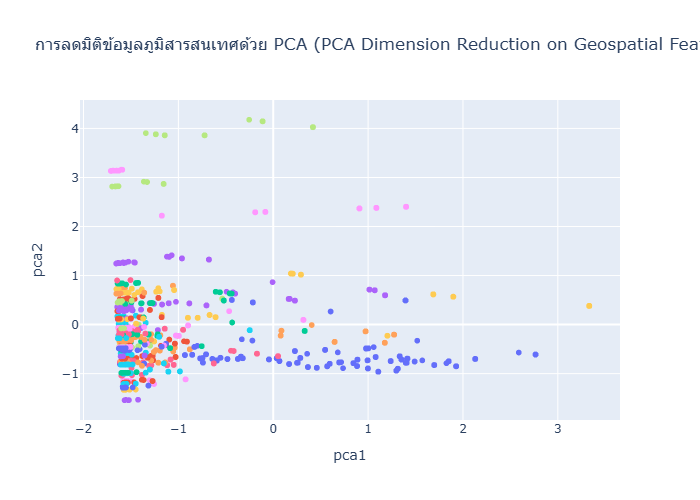

In [5]:
features = ['postcode_business_density', 'district_business_density', 'prov_vat_trend_slope']

print("1. สเกลข้อมูลให้มีค่าเฉลี่ยเป็น 0 และความเบี่ยงเบนมาตรฐานเป็น 1...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample[features])

print("2. รันโมเดล PCA เพื่อแปลงข้อมูลเป็น 2 ส่วนประกอบหลัก...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_sample['pca1'] = X_pca[:, 0]
df_sample['pca2'] = X_pca[:, 1]

print(f"อัตราการอธิบายความแปรปรวน (Explained Variance Ratio): {pca.explained_variance_ratio_}")
print(f"รวมอธิบายได้สะสม: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# แสดงกราฟการกระจายตัวของข้อมูลในปริภูมิ PCA แยกสีตามภาค/จังหวัดหลัก
fig_pca = px.scatter(
    df_sample.sample(n=min(5000, len(df_sample)), random_state=42), # สุ่ม 5000 จุดเพื่อความเร็วในการแสดงผลกราฟ
    x='pca1', 
    y='pca2', 
    color='จังหวัด',
    hover_data=['อำเภอ', 'business_age_years'],
    title='การลดมิติข้อมูลภูมิสารสนเทศด้วย PCA (PCA Dimension Reduction on Geospatial Features)'
)
fig_pca.update_layout(showlegend=False) # ปิด legend เพื่อให้กราฟอ่านง่ายขึ้นเนื่องจากจังหวัดมีจำนวนมาก
fig_pca.show()

## ขั้นตอนที่ 2.5/6: การจัดกลุ่มเพื่อแบ่งระดับความเสี่ยงเชิงพื้นที่ (K-Means Clustering on PCA)
เราใช้โมเดล **K-Means** บนตัวแปรที่ผ่านการทำ PCA แล้วเพื่อจัดกลุ่มรหัสไปรษณีย์/อำเภอ ออกเป็น 3 คลัสเตอร์หลักที่มีลักษณะพฤติกรรมและการเสียภาษีคล้ายกัน

กำลังคำนวณการจัดกลุ่ม K-Means ด้วย 3 คลัสเตอร์...


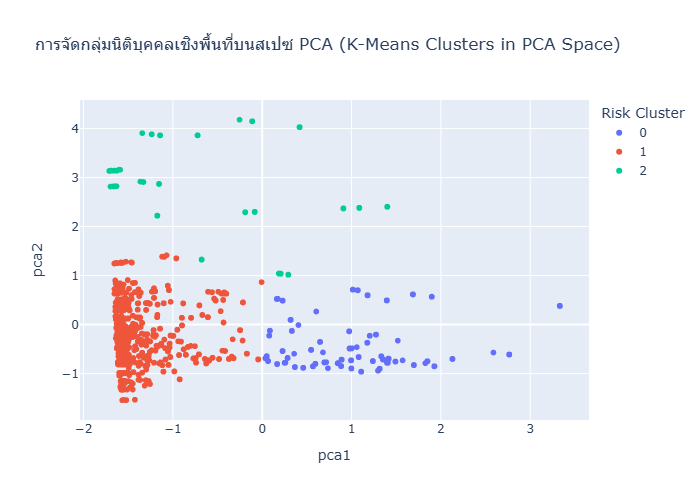


--- ตารางวิเคราะห์คุณสมบัติของแต่ละกลุ่มความเสี่ยง (Cluster Profile) ---


,risk_cluster,avg_age,avg_postcode_density,avg_vat_trend,total_records
0,0,12.664147,17977.337527,0.014491,43561
1,1,11.250808,2500.309587,0.025372,46562
2,2,10.727624,9121.094664,0.176645,9877


In [6]:
print("กำลังคำนวณการจัดกลุ่ม K-Means ด้วย 3 คลัสเตอร์...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_sample['risk_cluster'] = kmeans.fit_predict(X_pca)

# พล็อตกราฟการจับกลุ่มในแกน PCA ด้วยสีแยกตาม Cluster ID
fig_cluster = px.scatter(
    df_sample.sample(n=min(5000, len(df_sample)), random_state=42),
    x='pca1',
    y='pca2',
    color=df_sample.sample(n=min(5000, len(df_sample)), random_state=42)['risk_cluster'].astype(str),
    hover_data=['จังหวัด', 'อำเภอ', 'business_age_years'],
    labels={'color': 'Risk Cluster'},
    title='การจัดกลุ่มนิติบุคคลเชิงพื้นที่บนสเปซ PCA (K-Means Clusters in PCA Space)'
)
fig_cluster.show()

# สรุปข้อมูลของแต่ละ Cluster ออกมาให้ผู้ใช้เข้าใจความหมายของแต่ละกลุ่ม
cluster_summary = df_sample.groupby('risk_cluster').agg(
    avg_age=('business_age_years', 'mean'),
    avg_postcode_density=('postcode_business_density', 'mean'),
    avg_vat_trend=('prov_vat_trend_slope', 'mean'),
    total_records=('เลขผู้เสียภาษีอากร', 'count')
).reset_index()

print("\n--- ตารางวิเคราะห์คุณสมบัติของแต่ละกลุ่มความเสี่ยง (Cluster Profile) ---")
display(cluster_summary)

## ขั้นตอนที่ 7: โมเดลจำแนกความเสี่ยงทางธุรกิจ (Random Forest Classifier for Risk Group)
เรากำหนดนิยามของธุรกิจที่ **"เสี่ยงสูง (High Risk)"** คือ: ธุรกิจใหม่ที่เพิ่งตั้งไข่ (อายุน้อยกว่า 3 ปี) และอยู่ในจังหวัดที่รายได้จากการจัดเก็บภาษีอากรมีแนวโน้มหดตัว (Slope เป็นลบ)

โมเดลจำแนกประเภทข้อมูลนี้จะทำหน้าที่ทำนายโอกาสในการตกเป็นนิติบุคคลความเสี่ยงสูงนี้ โดยใช้ฟีเจอร์เชิงพื้นที่ และแสดงประสิทธิภาพด้วยการพล็อต **ROC Curve และหาค่า AUC**

จำนวนเคสผู้ประกอบการเสี่ยงสูง: 1968 ราย จากทั้งหมด 100,000 ราย
กำลังสอนคอมพิวเตอร์สร้างโมเดล Random Forest Classifier...



--- รายงานผลประสิทธิภาพโมเดล (Classification Report) ---
              precision    recall  f1-score   support

           0       1.00      0.92      0.96     19606
           1       0.20      1.00      0.33       394

    accuracy                           0.92     20000
   macro avg       0.60      0.96      0.64     20000
weighted avg       0.98      0.92      0.94     20000

พื้นที่ใต้เส้น ROC (AUC Score): 0.9622


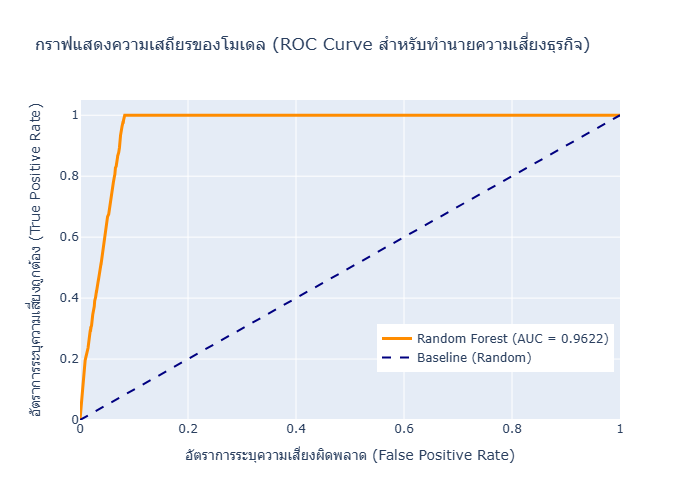

In [7]:
df_sample['is_high_risk'] = ((df_sample['business_age_years'] < 3.0) & (df_sample['prov_vat_trend_slope'] < 0.0)).astype(int)
print(f"จำนวนเคสผู้ประกอบการเสี่ยงสูง: {df_sample['is_high_risk'].sum()} ราย จากทั้งหมด {df_sample.shape[0]:,} ราย")

y_cls = df_sample['is_high_risk']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_pca, y_cls, test_size=0.2, stratify=y_cls, random_state=42)

print("กำลังสอนคอมพิวเตอร์สร้างโมเดล Random Forest Classifier...")
cls_model = RandomForestClassifier(n_estimators=50, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)
cls_model.fit(X_train_c, y_train_c)

probs = cls_model.predict_proba(X_test_c)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_c, probs)
roc_auc = auc(fpr, tpr)

print("\n--- รายงานผลประสิทธิภาพโมเดล (Classification Report) ---")
preds = cls_model.predict(X_test_c)
print(classification_report(y_test_c, preds))
print(f"พื้นที่ใต้เส้น ROC (AUC Score): {roc_auc:.4f}")

# พล็อต ROC Curve ด้วย Plotly เพื่อให้สามารถโฮเวอร์ดูจุดตัดสินใจได้ (Interactive Thresholds)
fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'Random Forest (AUC = {roc_auc:.4f})', line=dict(color='darkorange', width=3)))
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Baseline (Random)', line=dict(color='navy', dash='dash')))
fig_roc.update_layout(
    title='กราฟแสดงความเสถียรของโมเดล (ROC Curve สำหรับทำนายความเสี่ยงธุรกิจ)',
    xaxis_title='อัตราการระบุความเสี่ยงผิดพลาด (False Positive Rate)',
    yaxis_title='อัตราการระบุความเสี่ยงถูกต้อง (True Positive Rate)',
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1.05]),
    legend=dict(x=0.55, y=0.15)
)
fig_roc.show()

## ขั้นตอนที่ 8: โมเดลพยากรณ์อายุขัยธุรกิจ (Random Forest Regressor)
พยากรณ์ความยืนยาวของธุรกิจผ่านตัวแปรตัวเลขต่อเนื่อง (`business_age_years`) และสร้างแผนภูมิแสดงสัดส่วนน้ำหนักความสำคัญของปัจจัยแต่ละอย่าง

กำลังสอนคอมพิวเตอร์สร้างโมเดล Random Forest Regressor...


ค่าความคลาดเคลื่อนเฉลี่ย (Test RMSE): 8.9485 ปี


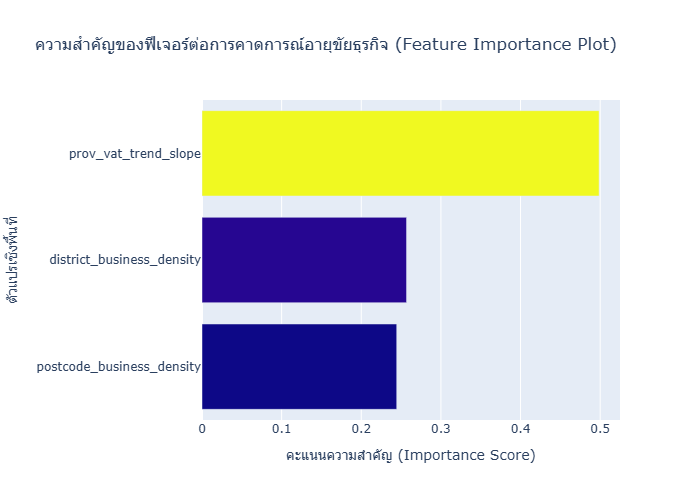

In [8]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(df_sample[features], df_sample['business_age_years'], test_size=0.2, random_state=42)

print("กำลังสอนคอมพิวเตอร์สร้างโมเดล Random Forest Regressor...")
reg_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
reg_model.fit(X_train_r, y_train_r)

preds_reg = reg_model.predict(X_test_r)
rmse = np.sqrt(mean_squared_error(y_test_r, preds_reg))
print(f"ค่าความคลาดเคลื่อนเฉลี่ย (Test RMSE): {rmse:.4f} ปี")

# สกัดสัดส่วนความสำคัญของคุณลักษณะ
feat_imp = pd.Series(reg_model.feature_importances_, index=features).sort_values(ascending=True)

fig_imp = px.bar(
    x=feat_imp.values, 
    y=feat_imp.index, 
    orientation='h',
    title='ความสำคัญของฟีเจอร์ต่อการคาดการณ์อายุขัยธุรกิจ (Feature Importance Plot)',
    labels={'x': 'คะแนนความสำคัญ (Importance Score)', 'y': 'ตัวแปรเชิงพื้นที่'},
    color=feat_imp.values,
    color_continuous_scale='Plasma'
)
fig_imp.update_layout(coloraxis_showscale=False)
fig_imp.show()

## บทสรุปสำหรับผู้เริ่มต้น

1. **ความสำคัญของพื้นที่ทางภูมิศาสตร์:** จากกราฟ Feature Importance จะเห็นว่า `postcode_business_density` มีผลอย่างมีนัยสำคัญ หมายความว่าความหนาแน่นของผู้เล่นในระดับรหัสไปรษณีย์เดียวกันส่งผลต่ออายุขัยของธุรกิจอย่างชัดเจน
2. **การรวมข้อมูลระดับมหภาค:** การเชื่อมข้อมูลเชิงพื้นที่ร่วมกับชีพจรภาษีอารายจังหวัด (`prov_vat_trend_slope`) ช่วยให้ตัวแปรในโมเดลมีมิติเชิงเศรษฐกิจแฝงอยู่ ส่งผลให้โมเดลประเมินความเสี่ยงได้อย่างสมจริงยิ่งขึ้น
3. **กระบวนการถัดไป:** ผู้ใช้สามารถนำพิกัดเส้นรุ้งเส้นแวงจริง (Latitude/Longitude) ของรหัสไปรษณีย์มาเชื่อมต่อเพื่อวาดกราฟเป็นแผนที่แบบ Geo-Map ใน Plotly ได้เพิ่มเติมในอนาคต